In [1]:
import pandas as pd

ndvi_df = pd.read_csv(
    "../outputs/makueni_monthly_ndvi_2020_2024.csv"
)

rain_df = pd.read_csv(
    "../outputs/makueni_monthly_rainfall_2020_2024.csv"
)

In [2]:
ndvi_df.head()

,month,mean_ndvi
0,2020-01-01,0.585498
1,2020-02-01,0.626168
2,2020-03-01,0.602552
3,2020-04-01,0.554790
4,2020-05-01,0.478910


In [3]:
rain_df.head()

,month,rainfall_mm
0,2020-01-01,118.317911
1,2020-02-01,56.757018
2,2020-03-01,171.246656
3,2020-04-01,202.196964
4,2020-05-01,22.359689


In [4]:
ndvi_df["month"] = pd.to_datetime(
    ndvi_df["month"]
)

rain_df["month"] = pd.to_datetime(
    rain_df["month"]
)

In [5]:
combined_df = ndvi_df.merge(
    rain_df,
    on="month"
)

In [6]:
combined_df.head()

,month,mean_ndvi,rainfall_mm
0,2020-01-01,0.585498,118.317911
1,2020-02-01,0.626168,56.757018
2,2020-03-01,0.602552,171.246656
3,2020-04-01,0.554790,202.196964
4,2020-05-01,0.478910,22.359689


In [7]:
combined_df.to_csv(
    "../outputs/makueni_ndvi_rainfall_2020_2024.csv",
    index=False
)

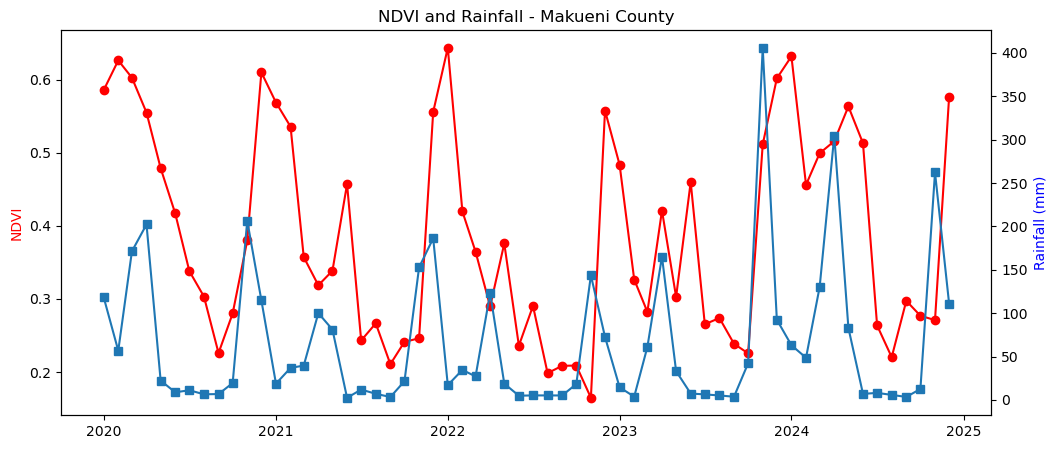

In [8]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(
    combined_df["month"],
    combined_df["mean_ndvi"],
    marker="o",
    label="NDVI",
    color="red"
)

ax1.set_ylabel("NDVI", color="red")

ax2 = ax1.twinx()

ax2.plot(
    combined_df["month"],
    combined_df["rainfall_mm"],
    marker="s",
    label="Rainfall"
)

ax2.set_ylabel("Rainfall (mm)", color="blue")

plt.title("NDVI and Rainfall - Makueni County")

plt.show()

In [9]:
combined_df[
    ["mean_ndvi", "rainfall_mm"]
].corr()

,mean_ndvi,rainfall_mm
mean_ndvi,1.000000,0.333115
rainfall_mm,0.333115,1.000000


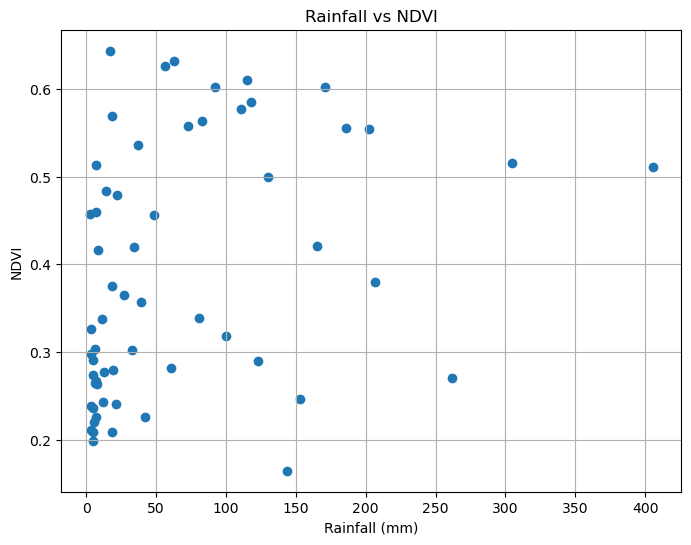

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    combined_df["rainfall_mm"],
    combined_df["mean_ndvi"]
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("NDVI")
plt.title("Rainfall vs NDVI")

plt.grid(True)

plt.show()

In [11]:
combined_df["rainfall_lag1"] = (
    combined_df["rainfall_mm"]
    .shift(1)
)

In [12]:
combined_df[
    ["mean_ndvi", "rainfall_lag1"]
].corr()

,mean_ndvi,rainfall_lag1
mean_ndvi,1.000000,0.706176
rainfall_lag1,0.706176,1.000000


In [13]:
combined_df["rainfall_lag2"] = (
    combined_df["rainfall_mm"]
    .shift(2)
)

In [14]:
combined_df[
    ["mean_ndvi", "rainfall_lag2"]
].corr()

,mean_ndvi,rainfall_lag2
mean_ndvi,1.000000,0.527973
rainfall_lag2,0.527973,1.000000


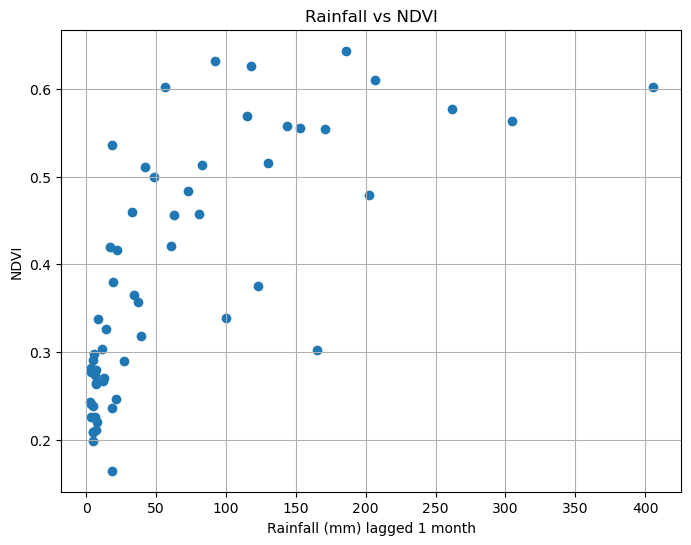

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    combined_df["rainfall_lag1"],
    combined_df["mean_ndvi"]
)

plt.xlabel("Rainfall (mm) lagged 1 month")
plt.ylabel("NDVI")
plt.title("Rainfall vs NDVI")

plt.grid(True)

plt.show()

In [16]:
combined_df.sort_values(
    "rainfall_mm",
    ascending=False
).head()

,month,mean_ndvi,rainfall_mm,rainfall_lag1,rainfall_lag2
46,2023-11-01,0.511180,405.738460,42.187587,3.704895
51,2024-04-01,0.515720,304.464194,130.267565,48.600838
58,2024-11-01,0.271003,262.100963,12.638006,3.470424
10,2020-11-01,0.380012,206.395682,19.448646,6.753315
3,2020-04-01,0.554790,202.196964,171.246656,56.757018
